<!-- open-in-badges -->
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_1_senal_inicializacion.ipynb) [![Abrir en Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_1_senal_inicializacion.ipynb) [![Abrir en Lightning Studio](https://pl-bolts-doc-images.s3.us-east-2.amazonaws.com/app-2/studio-badge.svg)](https://lightning.ai/new?repo_url=https%3A%2F%2Fgithub.com%2FEAFIT-IA%2Fsi7011-DeepLearning%2Fblob%2Fmain%2Fsessions%2F02_deep_training%2Fnotebooks%2Fsesion_02_1_senal_inicializacion.ipynb)

# SI7011 · Sesión 02 · 1. Señal e inicialización
**Juan David Martínez Vargas · Universidad EAFIT**

| Sección | Lo que cambia | Qué mirar |
|---|---|---|
| 1 | MLP de 20 capas con tanh e inicialización por defecto | la std de las activaciones, capa por capa |
| 2 | pesos pequeños, $\mathcal N(0, 0.01^2)$ | la señal desaparece |
| 3 | pesos grandes, $\mathcal N(0, 1)$ | tanh se satura en ±1 |
| 4 | Xavier | la escala se conserva mucho mejor |
| 5 | ReLU: por defecto, Xavier y He | por qué ReLU necesita He |
| 6 | el gradiente en cada capa | la señal que viaja hacia atrás |
| 7 | pérdida inicial frente a $\ln C$ | una verificación de 1 segundo |
| 8 | entrenar 5 épocas | ¿predijo bien la inspección? |

Corre en CPU en 1–2 minutos (Colab, Kaggle, Lightning o local).

In [1]:
import copy, math, time
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import torch
from torch import nn
from torchvision import datasets

torch.manual_seed(0)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
int_epochs = lambda: plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
print('PyTorch', torch.__version__)

PyTorch 2.14.1+cu130


## Datos: Fashion-MNIST como vectores
Son los mismos datos en los cuatro notebooks de la sesión. Cada imagen de 28×28 se aplana en un vector de 784 valores. Se usan 10 000 ejemplos de entrenamiento, 10 000 de validación (tomados del resto del conjunto de entrenamiento) y el conjunto de prueba oficial. El escalado se calcula **solo** con entrenamiento.

In [2]:
train_set = datasets.FashionMNIST('data', train=True, download=True)
test_set = datasets.FashionMNIST('data', train=False, download=True)
CLASSES = train_set.classes

# imagen 28×28 → vector x ∈ ℝ⁷⁸⁴ con píxeles en [0, 1]
X = train_set.data.reshape(-1, 784).float() / 255
y = train_set.targets  # y ∈ {0, …, 9}: C = 10 clases
perm = torch.randperm(len(X), generator=torch.Generator().manual_seed(0))
# entrenamiento: con estos ejemplos se calcula ∇J
X_train, y_train = X[perm[:10_000]], y[perm[:10_000]]
X_val, y_val = X[perm[50_000:]], y[perm[50_000:]]  # validación: J_val, para comparar decisiones
# prueba: se usa una sola vez, al final
X_test, y_test = test_set.data.reshape(-1, 784).float() / 255, test_set.targets

# Estandarizar deja las entradas con media 0 y varianza 1. Las fórmulas de inicialización
# suponen esa escala: Var(z_1) = n_in · Var(W_1) · E[a_0²] con a_0 = x.
mu, sd = X_train.mean(), X_train.std()          # estadísticas solo de entrenamiento
X_train, X_val, X_test = [(t - mu) / sd for t in (X_train, X_val, X_test)]
X_train.shape, X_val.shape, X_test.shape

(torch.Size([10000, 784]), torch.Size([10000, 784]), torch.Size([10000, 784]))

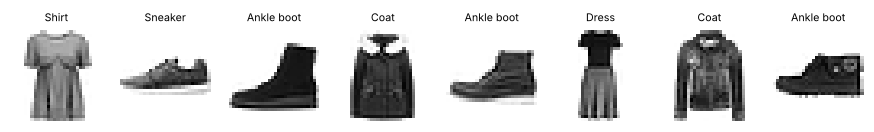

In [3]:
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for ax, img, lab in zip(axes, train_set.data[perm[:8]], train_set.targets[perm[:8]]):
    ax.imshow(img, cmap='gray_r'); ax.set_title(CLASSES[lab], fontsize=7); ax.axis('off')
plt.show()

## Herramientas: entrenar, evaluar y graficar
Es el mismo loop de la sesión 01 y se define una sola vez. Lo que cambia en cada sección es el **modelo** o el **optimizador**.

In [4]:
# L_i = −log softmax(f_θ(x_i))_{y_i}; recibe logits y aplica log_softmax por dentro
loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, opt, batch_size=128):
    model.train()  # modo entrenamiento: Dropout activo, BatchNorm con estadísticas del lote
    perm = torch.randperm(len(X_train))  # orden nuevo en cada época → mini-lotes 𝓑_t distintos
    total = 0.0
    for i in range(0, len(X_train), batch_size):
        b = perm[i:i + batch_size]  # índices del mini-lote 𝓑_t
        loss = loss_fn(model(X_train[b]), y_train[b])  # J_𝓑(θ) = (1/|𝓑|) Σ_{i∈𝓑} L_i(θ)
        # borrar g anterior · g_t = ∇_θ J_𝓑 (backprop) · θ ← regla del optimizador
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * len(b)  # promedio de la época ≈ J sobre entrenamiento
    return total / len(X_train)

@torch.no_grad()  # sin grafo: al evaluar no hay backward
def evaluate(model, X, y):
    model.eval()  # modo evaluación: Dropout apagado, BatchNorm con promedios móviles
    logits = model(X)
    # J_val y accuracy; la clase predicha es argmax de los logits (softmax no cambia el orden)
    return loss_fn(logits, y).item(), (logits.argmax(1) == y).float().mean().item()

In [5]:
def fit(model, opt, epochs=10, batch_size=128):
    hist = {'loss': [], 'val_loss': [], 'val_acc': []}
    t0 = time.time()
    for epoch in range(epochs):
        hist['loss'].append(train_epoch(model, opt, batch_size))
        val_loss, val_acc = evaluate(model, X_val, y_val)
        hist['val_loss'].append(val_loss); hist['val_acc'].append(val_acc)
    print(f"época {epochs}: loss {hist['loss'][-1]:.3f} · val_loss {val_loss:.3f} · val_acc {val_acc:.3f} · {time.time() - t0:.1f} s")
    return hist

def plot_curves(hists, key='loss', title='', logy=False):
    for name, h in hists.items():
        plt.plot(range(1, len(h[key]) + 1), h[key], label=name)
    if logy: plt.yscale('log')
    plt.xlabel('época'); plt.ylabel(key); plt.title(title); plt.legend(); int_epochs(); plt.show()

## Un MLP profundo y una forma de mirar adentro
`deep_mlp` construye $D$ capas `Linear` + activación $\phi$ y recibe una función `init` para los pesos. `activation_stds` registra un *forward hook* en cada activación: es una función que PyTorch llama cada vez que esa capa produce su salida $a_l$, y aquí guarda $\operatorname{std}(a_l)$.

In [6]:
# z_l = W_l a_{l−1} + b_l,   a_l = φ(z_l),   a_0 = x,   l = 1, …, D
def deep_mlp(act=nn.Tanh, depth=20, width=128, init=None):
    layers, n_in = [], 784
    for _ in range(depth):
        # Linear: z_l = W_l a_{l−1} + b_l · act: a_l = φ(z_l)
        layers += [nn.Linear(n_in, width), act()]
        n_in = width
    model = nn.Sequential(*layers, nn.Linear(width, 10))
    if init is not None:
        for m in model:
            if isinstance(m, nn.Linear):
                # W_l con la escala elegida; b_l = 0 para no sumar varianza
                init(m.weight); nn.init.zeros_(m.bias)
    return model

# std(a_l) en cada capa, sin modificar el modelo: un forward hook se ejecuta cada vez que
# el módulo produce su salida (diapositiva *Preserve variance across layers*).
def activation_stds(model, x):
    stds = []
    # out = a_l, la salida de la activación φ en la capa l
    hooks = [m.register_forward_hook(lambda mod, inp, out: stds.append(out.std().item()))
             for m in model if not isinstance(m, nn.Linear)]
    with torch.no_grad():
        model(x)
    for h in hooks:
        h.remove()
    return stds

def plot_stds(curves, title=''):
    for name, s in curves.items():
        plt.plot(range(1, len(s) + 1), s, marker='o', ms=3, label=name)
    plt.yscale('log'); plt.xlabel('capa $l$'); plt.ylabel('std($a_l$)'); plt.title(title); plt.legend(); int_epochs(); plt.show()

x = X_train[:512]  # el mismo lote para todas las mediciones

## 1. Inicialización por defecto de PyTorch

In [7]:
torch.manual_seed(0)
# Por defecto nn.Linear usa U(−1/√n_in, 1/√n_in): Var(W) = 1/(3 n_in), un tercio de 1/n_in
s_default = activation_stds(deep_mlp(nn.Tanh), x)
print(' '.join(f'{s:.3f}' for s in s_default))

0.443 0.254 0.147 0.102 0.077 0.071 0.066 0.061 0.065 0.057 0.060 0.065 0.067 0.063 0.066 0.060 0.063 0.061 0.056 0.054


La std pasa de 0.44 en la primera capa a cerca de 0.05 en la última. PyTorch inicializa `nn.Linear` con $\mathcal U(-1/\sqrt{n_\text{in}},\,1/\sqrt{n_\text{in}})$, es decir, $\operatorname{Var}(W)=1/(3n_\text{in})$: un tercio de lo que haría falta para conservar la varianza.

## 2. Pesos pequeños: $\mathcal N(0, 0.01^2)$
**Cambia un argumento:** `init`.

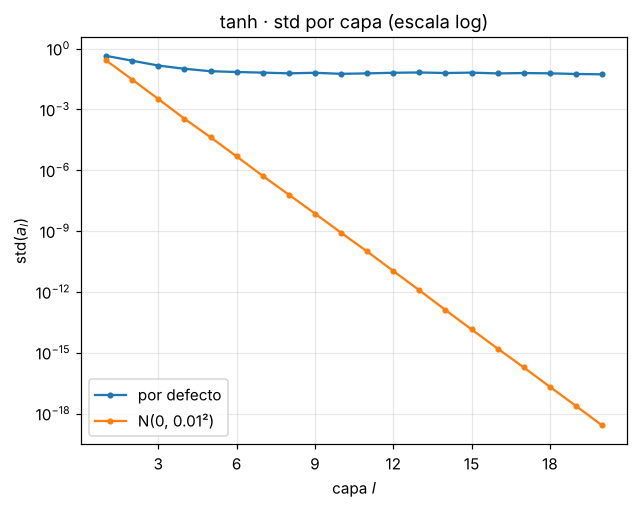

In [8]:
torch.manual_seed(0)
# Var(W) = 10⁻⁴ → factor por capa n_in · Var(W) = 128 · 10⁻⁴ ≈ 0.013 (tanh ≈ identidad cerca de 0)
s_small = activation_stds(deep_mlp(nn.Tanh, init=lambda w: nn.init.normal_(w, 0, 0.01)), x)
plot_stds({'por defecto': s_default, 'N(0, 0.01²)': s_small}, title='tanh · std por capa (escala log)')

Cada capa multiplica la varianza por $n_\text{in}\operatorname{Var}(W) = 128 \cdot 10^{-4} \approx 0.013$. Después de 20 capas la red entrega prácticamente cero, sin importar la entrada.

## 3. Pesos grandes: $\mathcal N(0, 1)$

In [9]:
torch.manual_seed(0)
# Var(W) = 1 → n_in · Var(W) = 128: |z_l| enorme
big = deep_mlp(nn.Tanh, init=lambda w: nn.init.normal_(w, 0, 1))
s_big = activation_stds(big, x)
with torch.no_grad():
    a_last = big[:-1](x)  # salida de la última tanh; |a| ≈ 1 significa tanh'(z) ≈ 0
print(f'std en la capa 20: {s_big[-1]:.3f} · fracción con |a| > 0.99: {(a_last.abs() > 0.99).float().mean():.0%}')

std en la capa 20: 0.963 · fracción con |a| > 0.99: 81%


La std no cae, pero eso no es una buena noticia: casi todas las unidades están **saturadas** en ±1. Allí $\tanh'(z)\approx 0$, así que el gradiente no puede atravesar la red.

## 4. Xavier / Glorot: $\operatorname{Var}(W) = 2/(n_\text{in}+n_\text{out})$

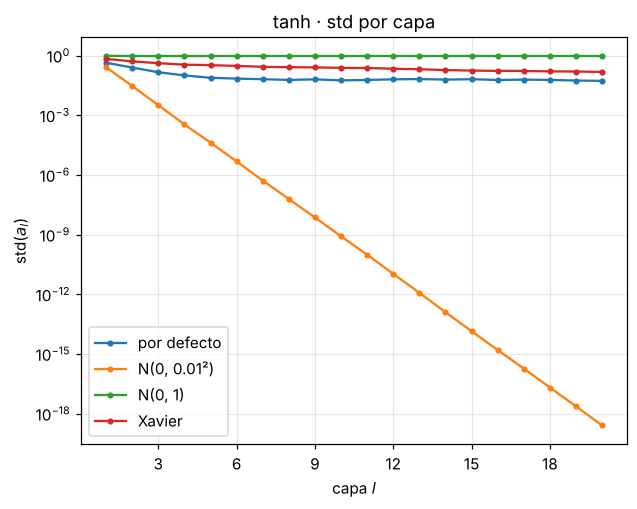

In [10]:
torch.manual_seed(0)
# Xavier: Var(W) = 2/(n_in + n_out) = 1/128 aquí → factor ≈ 1 por capa
s_xavier = activation_stds(deep_mlp(nn.Tanh, init=nn.init.xavier_normal_), x)
plot_stds({'por defecto': s_default, 'N(0, 0.01²)': s_small, 'N(0, 1)': s_big, 'Xavier': s_xavier},
          title='tanh · std por capa')

Con Xavier, la escala decae despacio y se mantiene lejos tanto de cero como de la saturación. Es la inicialización que se diseñó para activaciones simétricas como tanh.

## 5. ReLU: por defecto, Xavier y He
**Cambia la activación:** `nn.Tanh` → `nn.ReLU`. ReLU anula la mitad de las entradas, así que se pierde la mitad de la varianza en cada capa. He compensa con $\operatorname{Var}(W)=2/n_\text{in}$.

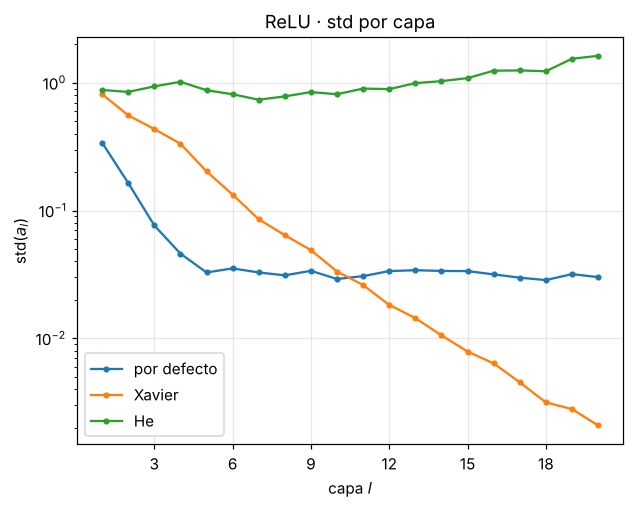

In [11]:
# He: Var(W) = 2/n_in; el 2 compensa la mitad que anula ReLU
he = lambda w: nn.init.kaiming_normal_(w, nonlinearity='relu')
curves = {}
for name, init in [('por defecto', None), ('Xavier', nn.init.xavier_normal_), ('He', he)]:
    torch.manual_seed(0)
    # con ReLU, E[a²] = ½ Var(z): el factor por capa es n_in · Var(W) / 2
    curves[name] = activation_stds(deep_mlp(nn.ReLU, init=init), x)
plot_stds(curves, title='ReLU · std por capa')

Con ReLU, Xavier pierde un factor cercano a 2 en cada capa y termina dos órdenes de magnitud por debajo. **He** es la única de las tres que mantiene la escala a lo largo de las 20 capas.

## 6. El gradiente en cada capa
Ahora miramos hacia atrás: $\lVert\nabla_{W_l}J\rVert$ después de un `backward()` sobre un lote.

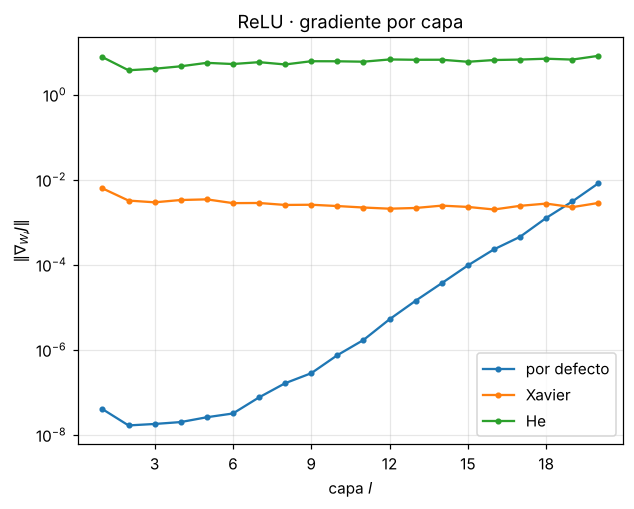

In [12]:
# ‖∇_{W_l} J‖ por capa. Hacia atrás, δ_{a_{l−1}} = W_lᵀ (φ'(z_l) ⊙ δ_{a_l}): con la escala equivocada,
# δ se multiplica por el mismo factor en cada capa, ahora de la salida hacia la entrada.
def grad_norms(model, x, y):
    model.zero_grad()
    loss_fn(model(x), y).backward()  # llena m.weight.grad = ∇_{W_l} J en cada capa
    return [m.weight.grad.norm().item() for m in model if isinstance(m, nn.Linear)][:-1]

grads = {}
for name, init in [('por defecto', None), ('Xavier', nn.init.xavier_normal_), ('He', he)]:
    torch.manual_seed(0)
    grads[name] = grad_norms(deep_mlp(nn.ReLU, init=init), x, y_train[:512])
for name, g in grads.items():
    plt.plot(range(1, len(g) + 1), g, marker='o', ms=3, label=name)
plt.yscale('log'); plt.xlabel('capa $l$'); plt.ylabel(r'$\|\nabla_{W_l} J\|$'); plt.title('ReLU · gradiente por capa'); plt.legend(); int_epochs(); plt.show()

Con la inicialización por defecto, el gradiente se encoge a medida que viaja hacia atrás: la primera capa recibe del orden de $10^{-8}$, unos **cien millones de veces** menos que con He. Si el gradiente no llega, esas capas no aprenden. Xavier queda en un punto intermedio, con gradientes pequeños pero parejos.

## 7. Verificación de 1 segundo: la pérdida inicial
Antes de aprender, un modelo bien inicializado debería predecir casi uniforme sobre las $C$ clases, así que su pérdida inicial debería estar cerca de $\ln C$.

In [13]:
# Si el modelo predice p_k = 1/C para toda clase: L_i = −log(1/C) = ln C
print(f'ln 10 = {math.log(10):.3f}')
for name, init in [('por defecto', None), ('N(0, 1)', lambda w: nn.init.normal_(w, 0, 1)), ('He', he)]:
    torch.manual_seed(0)
    with torch.no_grad():
        print(f'{name:12s} pérdida inicial = {loss_fn(deep_mlp(nn.ReLU, init=init)(x), y_train[:512]).item():.3g}')

ln 10 = 2.303
por defecto  pérdida inicial = 2.3
N(0, 1)      pérdida inicial = 8.22e+19
He           pérdida inicial = 4.37


- `N(0, 1)` da una pérdida absurda: los logits explotan. Es una alarma inmediata.
- La inicialización **por defecto** pasa la verificación, pero solo porque la red entrega casi cero (sección 5). Pasar la verificación no basta.
- **He** queda por encima de $\ln 10$ porque la última capa también se escaló con He y los logits salen grandes. Lo arreglamos inicializando **solo la capa de salida** con ceros:

In [14]:
torch.manual_seed(0)
model = deep_mlp(nn.ReLU, init=he)
nn.init.zeros_(model[-1].weight)  # logits = 0 → softmax uniforme → pérdida inicial = ln 10
with torch.no_grad():
    print(f'He + salida en cero: pérdida inicial = {loss_fn(model(x), y_train[:512]).item():.3f}')

He + salida en cero: pérdida inicial = 2.303


## 8. ¿Predice la inspección lo que pasa al entrenar?
La misma red de 20 capas con ReLU, el mismo optimizador (SGD con momentum, $\eta=0.01$) y 5 épocas. Solo cambia `init`.

época 5: loss 2.303 · val_loss 2.303 · val_acc 0.102 · 2.3 s


época 5: loss 1.247 · val_loss 0.986 · val_acc 0.590 · 2.5 s


época 5: loss 0.567 · val_loss 0.577 · val_acc 0.792 · 3.3 s


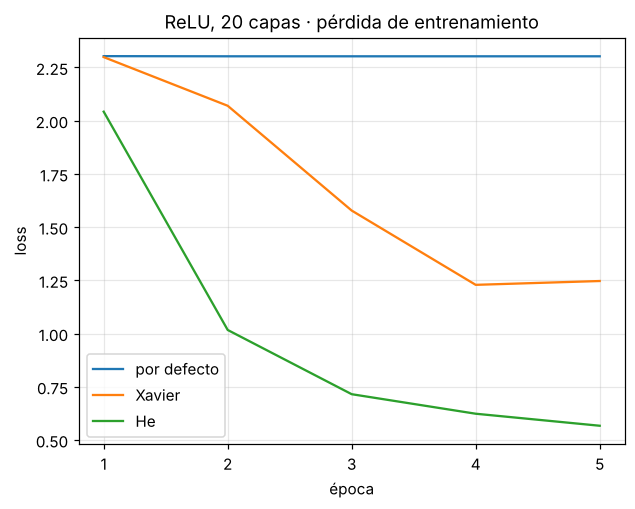

In [15]:
hists = {}
for name, init in [('por defecto', None), ('Xavier', nn.init.xavier_normal_), ('He', he)]:
    torch.manual_seed(0)
    model = deep_mlp(nn.ReLU, init=init)
    # mismos datos y optimizador: solo cambia la escala inicial de W
    hists[name] = fit(model, torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9), epochs=5)
plot_curves(hists, title='ReLU, 20 capas · pérdida de entrenamiento')

El orden de las curvas es el que anticiparon las secciones 5 y 6: con la inicialización por defecto la pérdida queda en $\ln 10$, con Xavier baja despacio y con He es la que más rápido aprende. **Se puede descartar una mala configuración antes de entrenar.**

En el notebook 3, BatchNorm resuelve este mismo problema por otro camino, y en el notebook 4 lo resuelven las conexiones residuales.

## Tu turno · 10 minutos
Copia una celda, cambia **una** cosa y compara.

1. Repite la sección 5 con `depth=50`. ¿Sigue estable He? ¿Qué pasa con Xavier?
2. Usa `nn.Tanh` con He. ¿La std crece o decrece con la profundidad? ¿Por qué?
3. Cambia `width=128` por `width=512` en la sección 2. ¿Se desvanece más rápido o más lento? Usa $n_\text{in}\operatorname{Var}(W)$ para predecirlo antes de correr.
4. Prueba `nn.LeakyReLU(0.1)` con `nn.init.kaiming_normal_(w, a=0.1, nonlinearity='leaky_relu')`.
5. En la sección 8, entrena con He pero con la capa de salida en cero (sección 7). ¿Cambia la primera época?

**Para pensar.** La inicialización por defecto pasa la verificación de $\ln C$ y aun así no entrena. ¿Qué medición de este notebook lo habría revelado primero?

In [16]:
# Experimento 1: sección 5 con depth=50


### Referencias
- Glorot y Bengio (2010), *Understanding the difficulty of training deep feedforward neural networks*, AISTATS.
- He, Zhang, Ren y Sun (2015), *Delving deep into rectifiers*, ICCV.
- [PyTorch · `torch.nn.init`](https://docs.pytorch.org/docs/stable/nn.init.html) y [`register_forward_hook`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_forward_hook).